<hr />

![header](img/Copernicus_header.jpg)

<h1 style="text-align: center;"><span style="color: #22689B;"><strong>Copernicus Marine Service Training Workshops</strong></span></h1>
<p>&nbsp;</p>
<h2 style="text-align: center;"><span style="color: #22689B;">Assessing Ecosystems Health</span></h2>
<p>&nbsp;</p>
<h2 style="text-align: center;"><span style="color: #22689B;"><strong>First Steps with Copernicus Marine Biogeochemical Products:</strong></span></h2>
<h2 style="text-align: center;"><span style="color: #22689B;"><strong>Data Download &amp; Visualization</strong></span></h2>

<h5 style="text-align: right;"><em>2023-09-09  BEGINNER LEVEL</em></h5>
<hr />

# <span style="color: #22689B;">**Table of Contents**</span>
1. [Introduction](#1.-Introduction)
1. [Data Download](#2.-Data-Download)
1. [Data Access](#3.-Data-Access)
1. [Visualization](#4.-Visualization)
1. [Conclusions](#5.-Conclusions)

<hr />
<hr />

# <span style="color: #22689B;">**1. Introduction**</span>
[Go back to the "Table of Contents"](#Table-of-Contents)

Marine ecosystems consist of abundant biological communities in seawater and the marine environment, functioning to facilitate energy flow, material circulation, and information transmission. As the largest ecosystem in the biosphere, they play a crucial role in regulating global climate, maintaining the water and carbon cycles in the biosphere.

A healthy marine ecosystem can be considered as a "living organism" with sustainable productivity, metabolic vitality, internal structural maintenance capability, self-control and maintenance, threat-response, and resilience.

Human activities have a profound impact on the health of the marine ecosystem, resulting in direct or cumulative effects that can lead to its deterioration.

Various methods have been employed to assess the health of marine ecosystems, including the Ocean Health Index (OHI), bio-evaluation methods, and indicator framework approaches.

The indicator framework method is based on the selection of appropriate evaluation indicators, the clarification of indicator weights, and the determination of suitable evaluation criteria. The objective is to answer three key questions: what happened, why it happened, and how humans should respond. The Driver-Pressure-State-Impact-Response (DPSIR) model, jointly developed by the United Nations Environment Programme and the European Environment Agency, is one of the most widely used conceptual frameworks and reporting tools for assessing and monitoring ecosystem health.

<p><img style="display: block; margin-left: auto; margin-right: auto;" src="img/DPSRI_conceptual_model.gif" alt="" /></p>
<p style="text-align: center;"><em>The DPSRI conceptual model for the ecosystem health assessment <a href="https://doi.org/10.3389/fmars.2023.1115896">(Wu et al., 2023)</a>.</em></p>

The evaluation models incorporate several indicators, many of which are not directly related to the ocean. For example, the evaluation layers of Driving and Pressure utilize various socioeconomic indicators. However, in particular, concerning the evaluation layers of State and Impact, the models employ a range of variables that can be directly obtained or computed from Copernicus Marine products. For instance:

<ul>
<li>Acidification: SO2, Nox, NH3, nitrates, ammonia, HCl, HF, H2SO4.</li>
<li>Eutrophication: N, P concentration, COD, BOD, phytoplankton biomass/algal blooms, average chlorophyll-a concentration, dissolved oxygen (DO).</li>
<li>Turbidity</li>
<li>Maximum Tidal Range</li>
<li>Temperature and Salinity</li>
<li>Water Temperature</li>
<li>Disolved Organic Carbon (COD)</li>
<li>pH</li>
<li>Maximum offshore distance of sea ice outer line</li>
<li>Maximum wave impact</li>
</ul>

Given the vast variety of data that influences ecosystem health, the Copernicus Marine service can address many of these requirements through a wide range of datasets generated in diverse ways. Since it is impossible to cover this diversity in a single tutorial, the present course will focus on data generated through biogeochemical modeling. This type of database will allow us to visualize a large number of variables closely related to ecosystem health.

The objectives of this course are as follows:
1. To learn the data download procedures from the Copernicus Marine Service.
2. To understand how to access these databases using the Python programming language.
3. To create basic visualizations of the data.

This tutorial is presented in a Jupyter Notebook format using the Python language. This means that explanations alternate with Python code cells that show the procedures that a user can follow to perform various tasks. It is recommended that the user already has some basic knowledge of Python to understand the entirety of the code shown in the tutorial. However, it is not essential, and the tutorial is designed to be executed without prior knowledge.

### Setup
First of all, the python interpreter must import all the necessary tools and libraries from the Jupyter Notebook Ecosystem. The following cell compiles all the libraries that will be used during the tutorial:

**General Note**: Execute each cell through the <button class="btn btn-default btn-xs"><i class="icon-play fa fa-play"></i></button> button from the top MENU (or keyboard shortcut `Shift` + `Enter`).<br>







In [1]:
## Requested libraries

# To avoid warning messages
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import xarray as xr

import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

Below, you find the description and documentation of the libraries used:

| Module name | Description |
| :---: | :---|
| **numpy** | [NumPy](https://numpy.org/) is the fundamental package for scientific computing with Python and for managing ND-arrays |
| **xarray** | [Xarray](http://xarray.pydata.org/en/stable/) introduces labels in the form of dimensions, coordinates and attributes on top of raw NumPy-like arrays, which allows for a more intuitive, more concise, and less error-prone developer experience. |
| **matplotlib** |[Matplotlib](https://matplotlib.org/) is a Python 2D plotting library which produces publication quality figures |
| **cartopy** |[Cartopy](https://scitools.org.uk/cartopy/docs/latest/) is a library for plotting maps and geospatial data analyses in Python. |

### Bibliography

* Wu, W., Hu, J., & Song, D. (2023). Assessment of marine ecosystem health and its key influencing factors in Laizhou Bay, China. Frontiers in Marine Science, 10, 1115896, https://doi.org/10.3389/fmars.2023.1115896.



# <span style="color: #22689B;">**2. Data Download**</span>
[Go back to the "Table of Contents"](#Table-of-Contents)

The Copernicus service offers a wide variety of oceanographic data that can be used for a multitude of purposes. The most basic way to access the different products is through the Copernicus Marine website. However, there are various access methods that allow for the automation of data downloads, avoiding the need to go through the website.

The available products include observational, remote sensing, and modeling data. Each type of data has its own characteristics such as data availability at depth or only at the surface, spatial and temporal resolution, available variables (physical, biogeochemical), frequency of database updates, etc.

In this tutorial, we will use modeling data as they are among the most accessible for novice users and the ones that most easily allow the plotting of three-dimensional fields. Additionally, since the theme of the course is "Assessing Ecosystems Health," data from biogeochemical modeling will be used to demonstrate the wide range of data that Copernicus Services offer for assessing the vulnerability of ecosystems.

Below it is shown the identifier of the Copernicus product that will be used in this tutorial:

* **Global Analysis & Forecast:** [GLOBAL_ANALYSISFORECAST_BGC_001_028](https://doi.org/10.48670/moi-00015)

We encourage users to access the [Copernicus Marine Data Store](https://data.marine.copernicus.eu/products) to check how to download the required data for this tutorial with the following information:

|  |  |
| :---: | :---|
| **Copernicus product** | GLOBAL_ANALYSISFORECAST_BGC_001_028 |
| **Datasets** | cmems_mod_glo_bgc-pft_anfc_0.25deg_P1M-m |
| **Dates** | Any desired period including at least few months.<br>For example: Form May 2022 to May 2023 |

However, this tutorial focuses on the first steps for the visualization of oceanographic data, therefore the required data have already been previously downloaded and stored in the data directory of the JupyterHUB tutorial.

Alternatively, the user can download the data using the CMT subset option. To do that, you only have to copy the request from the Copernicus Data Store and run it on a system with CMT installed.
*CMT : Copernicus Marine Toolbox

The following code will send a request to Copernicus Services to download the desired dataset.

Please note that:

1. The following cell may take several minutes to run.



In [2]:
import copernicusmarine

# Data download
# Model Data

copernicusmarine.subset(
  dataset_id="cmems_mod_glo_bgc-pft_anfc_0.25deg_P1M-m",
  dataset_version="202311",
  variables=["chl", "phyc"],
  minimum_longitude=-180,
  maximum_longitude=179.75,
  minimum_latitude=-80,
  maximum_latitude=90,
  start_datetime="2022-01-01T00:00:00",
  end_datetime="2023-01-01T00:00:00",
  minimum_depth=0.4940253794193268,
  maximum_depth=0.4940253794193268,
  output_directory = "data"
)


INFO - 2025-02-06T14:44:37Z - You forced selection of dataset version "202311"
INFO - 2025-02-06T14:44:37Z - Dataset part was not specified, the first one was selected: "default"
INFO - 2025-02-06T14:44:38Z - Service was not specified, the default one was selected: "arco-geo-series"
INFO - 2025-02-06T14:44:39Z - Downloading using service arco-geo-series...
INFO - 2025-02-06T14:44:40Z - <xarray.Dataset> Size: 204MB
Dimensions:    (depth: 1, latitude: 681, longitude: 1440, time: 13)
Coordinates:
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 3kB -80.0 -79.75 -79.5 ... 89.5 89.75 90.0
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * time       (time) datetime64[ns] 104B 2022-01-01 2022-02-01 ... 2023-01-01
Data variables:
    chl        (time, depth, latitude, longitude) float64 102MB dask.array<chunksize=(1, 1, 681, 1440), meta=np.ndarray>
    phyc       (time, depth, latitude, longitude) float64 102MB dask.array<chunksize=(1, 1, 

  y


INFO - 2025-02-06T14:44:45Z - Writing to local storage. Please wait...


  0%|          | 0/106 [00:00<?, ?it/s]

INFO - 2025-02-06T14:44:48Z - Successfully downloaded to data/cmems_mod_glo_bgc-pft_anfc_0.25deg_P1M-m_chl-phyc_180.00W-179.75E_80.00S-90.00N_0.49m_2022-01-01-2023-01-01.nc


PosixPath('data/cmems_mod_glo_bgc-pft_anfc_0.25deg_P1M-m_chl-phyc_180.00W-179.75E_80.00S-90.00N_0.49m_2022-01-01-2023-01-01.nc')

You can visit the this [Help page](https://help.marine.copernicus.eu/en/articles/7970514-copernicus-marine-toolbox-installation) to get more information about how to install the CMT in your own computer.



# <span style="color: #22689B;">**3. Data Access**</span>
[Go back to the "Table of Contents"](#Table-of-Contents)

All the Copernicus Marine Service products are distibuted in the **NetCDF format**, which is a common way of storing scientific data. 
These NetCDF files contain three different objects:

* **Variables**: Multidimensional arrays of data.
* **Dimensions**: Special 1D variables used to define the dimensions of each variable.
* **Attributes**: Labels that can be attached to any variable or the dataset (global attributes).

The first step to start working is to open a netCDF file so that Python can access it. To do this, we use the [xarray](http://xarray.pydata.org/en/stable/) library, which we call using the abbreviation `xr.`

The code in the following cell uses the [open_dataset](https://docs.xarray.dev/en/stable/generated/xarray.open_dataset.html) function to open the file previously downloaded (`DataFileName`). The function creates a variable (`DS`) that will be used from now on to access the data in the file.

In [3]:
# Open Input Data File

# Variable including the path and name of the data file
DataFileName = 'data/cmems_mod_glo_bgc-pft_anfc_0.25deg_P1M-m_chl-phyc_180.00W-179.75E_80.00S-90.00N_0.49m_2022-01-01-2023-01-01.nc'
# Open the datafile
DS = xr.open_dataset(DataFileName)

# Show info of dataset
DS


<xarray.Dataset> Size: 204MB
Dimensions:    (depth: 1, latitude: 681, longitude: 1440, time: 13)
Coordinates:
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 3kB -80.0 -79.75 -79.5 ... 89.5 89.75 90.0
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * time       (time) datetime64[ns] 104B 2022-01-01 2022-02-01 ... 2023-01-01
Data variables:
    chl        (time, depth, latitude, longitude) float64 102MB ...
    phyc       (time, depth, latitude, longitude) float64 102MB ...
Attributes: (12/13)
    Conventions:                   CF-1.6
    area:                          GLOBAL
    contact:                       servicedesk.cmems@mercator-ocean.eu
    credit:                        E.U. Copernicus Marine Service Information...
    institution:                   Mercator Ocean
    licence:                       http://marine.copernicus.eu/services-portf...
    ...                            ...
    product_user_manual:           http://marine.copernicus.eu/documents/PUM/...
    quality_information_document:  http://marine.copernicus.eu/documents/QUID...
    references:                    http://marine.copernicus.eu
    source:                        MERCATOR BIOMER4V2R1
    title:                         Monthly mean fields for product GLOBAL_ANA...
    copernicusmarine_version:      1.2.4

As can be seen, the previous cell concludes with a command that requests to display the `DS` variable on the screen. This allows obtaining a report on the available data with three sections.

* At the last position, the ***attributes*** section appears, which stores general information about the data file. Given that these attributes apply to all data in the file, they are usually called *global attributes*.

* In the ***dimensions*** section, the name of the 1-D variables defined as dimensions in the file is displayed, as well as their length. In the case at hand, the file contains the dimensions `depth`, `latitude`, `longitude`, and `time`.

* In ***Coordinates*** and ***Variables***, the variables that store the data of each dimension (Coordinates) as well as the multidimensional variables stored are shown. In this case, we can see that the opened file contains variables called `chl` and `phyc` that depends on the dimensions `time`, `depth`, `latitude`, and `longitude`.

It is worth mentioning that in this report, the user can navigate and explore the data by clicking on the icons located to the right of each variable. This allows access to the list of particular attributes of each variable and a general visualization of the data.

However, the capabilities to access the data are infinitely greater if we access them using Python commands. One of the main goals of this tutorial is to show different ways of accessing the data.

# <span style="color: #22689B;">**4. Visualization**</span>
[Go back to the "Table of Contents"](#Table-of-Contents)

## Plot Maps

Once data access has been obtained, we are ready to start working with it. To begin, we will create a map of one variable stored in `DS`. Throughout this section, we will use the [cartopy](https://scitools.org.uk/cartopy/docs/latest/) library to create a map of sea surface temperature.

The first step to make any plot is to select the data to be plotted. This step is very important as it will be necessary for any type of plot we want to make.

In the case at hand, since our purpose is to make a map, we will have to select a set of data with a specific date and depth. To do this, we will use the [.sel](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.sel.html) function of xarray. This function is very useful because it allows us to access the data directly by the name and value of the dimensions we want to select.

The following cell selects data stored in the dataset `DS`. As a first example, it selects only the desired variable for a specific time frame.

The [squeeze()](https://numpy.org/doc/stable/reference/generated/numpy.squeeze.html) function used after the data selection collapses all dimensions that have a length of 1 after the selection process.

The two commented options below allow for a more refined data selection:

1. The first option enables the creation of a map for a specific region of the globe defined by a range of latitudes and longitudes.

1. The second option allows the user to create a data subset, thereby improving the performance of the code.


In [4]:
# Plot Map: Data Selection

VarName = 'chl'
Date = '2022-05-01'  #YYYY-MM
LatName = 'latitude'
LonName = 'longitude'

# Subseting a especific variable from the dataset DS
Data2Map = DS[VarName].sel(time = Date, method = 'nearest').squeeze()

# OPTIONAL 1: Subseting a range of lat values
#Data2Map = Data2Map.sel(latitude = slice(10, 35),      #Latitude min, Latitude max
#                        longitude = slice(-100, -60))  #Longitude min, Longitude max

# OPTIONAL 2: Subseting latitude and longitude selecting only every Skip-th value
#Skip = 4
#Data2Map = Data2Map.sel(latitude = slice(None, None, Skip),
#                        longitude = slice(None, None, Skip))

Data2Map

<xarray.DataArray 'chl' (latitude: 681, longitude: 1440)> Size: 8MB
[980640 values with dtype=float64]
Coordinates:
    depth      float32 4B 0.494
  * latitude   (latitude) float32 3kB -80.0 -79.75 -79.5 ... 89.5 89.75 90.0
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
    time       datetime64[ns] 8B 2022-05-01
Attributes:
    long_name:      Total Chlorophyll
    standard_name:  mass_concentration_of_chlorophyll_a_in_sea_water
    unit_long:      milligram of Chlorophyll per cubic meter
    units:          mg m-3
    valid_max:      50.0
    valid_min:      0.0

As we can see in the report of `Data2Map`, this variable stores data that only depends on two dimensions (`latitude` and `longitude`), therefore it is possible to use this data to plot a map.

Next, we will focus on the procedure for drawing maps of a variable. For this, we use various functions from the `matplotlib` and `cartopy` libraries, which we will call with the prefixes `plt.`, `ccrs.`, and `cfeature.`.

The following cell defines a function `PlotMap` that generates the map of the data stored in `Data2Map`. To facilitate understanding, the lines of code have been divided into four separate groups:
* <u>**Figure creation:**</u> This section includes the necessary commands to create a `figure` object and associate it with the graph axes, which, being the axes of a map, must be defined with some type of cartographic projection.
* <u>**Editing basic map features:**</u> This section includes a series of commands to define some aesthetic features of the map, such as the coastline, latitude and longitude gridlines, land mask, country borders, and map lat/lon limits.
* <u>**Command to plot the data:**</u> In this case, we will use the [pcolormesh](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pcolormesh.html) function that generates a pseudocolor plot of the data. The arguments of this function must be given in the following order: longitude, latitude, and Z values. The cmap argument is optional and only defines the color scale used.
* <u>**Final editing commands:**</u> The figure is finalized by including some editing commands, such as the inclusion of a formatted title and the color scale of the plot.

(<Figure size 1500x500 with 2 Axes>,
 <GeoAxes: title={'center': 'Variable: chl; Date: 2022-05-01'}>)

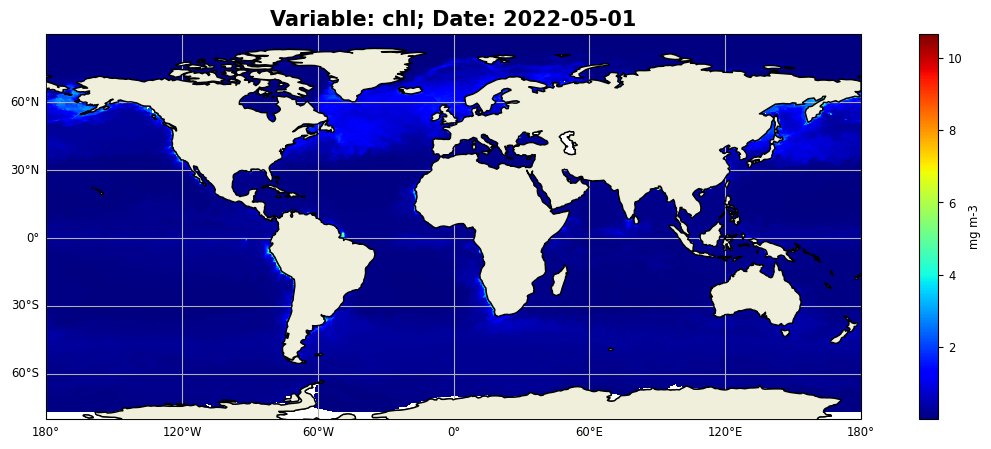

In [6]:
# Plot Map:

def PlotMap(Data, Title, Units):
    '''
    This function compiles the code lines needed to plot a map
    '''
    #1. Figure Creation
    Fig = plt.figure(figsize=(15, 5))                                # create new figure
    Ax = plt.axes(projection=ccrs.PlateCarree())                     # create axes with the map projection
    
    #2. Editing basic map features
    Ax.coastlines()                                                  # add the coastlines
    Gl = Ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)      # add the longitude / latitude lines
    Gl.right_labels = False                                          # remove latitude labels on the right
    Gl.top_labels = False                                            # remove longitude labels on the top
    Gl.xlabel_style = {'size': 'small'}                              # x-axis label properties
    Gl.ylabel_style = {'size': 'small'}                              # y-axis label properties
    Ax.add_feature(cfeature.LAND, zorder=10, edgecolor='k')          # add land mask
    Ax.add_feature(cfeature.BORDERS, linestyle=':')                  # add country borders
    #Ax.set_extent([-20, 35, -50, 20],crs=ccrs.PlateCarree())        # define the extent of the map [lon_min,lon_max,lat_min,lat_max]
    
    #3. Command to plot the data
    Map = Ax.pcolor(Data[LonName],                                   # Longitude data
                    Data[LatName],                                   # Latitude data
                    Data,                                            # Values to plot
                    #norm=matplotlib.colors.LogNorm(),               # Logaritmic normalization
                    cmap='jet')                                      # Define colormap

    #4. Final editing commands
    Ax.set_title(Title, fontsize=15, fontweight="bold")              # add a title to the figure
    CBar = plt.colorbar(Map, ax=Ax)                                  # add the colorbar
    CBar.ax.tick_params(labelsize='small')
    CBar.set_label(label=Units, fontsize='small')                    # format colorbar
    return Fig, Ax

MapTitle = 'Variable: {}; Date: {}'.format(VarName, Date)
PlotMap(Data2Map, MapTitle, Data2Map.units)


***
<div class="alert alert-block alert-info">
    
<h3>Exercises to explore:</h3>

* Modify the data selection box to plot other variables such as Phytoplankton `phyc`
* Explore the use of **Option 1** in data selection to improve the code performance.
* Explore the use of **Option 2** in data selection to plot a especific region of the world.
* Explore the use of logaritmic normalization to improve the visualization of variables.
    * For this exercise see the results uncomenting the line: `norm=matplotlib.colors.LogNorm(),`
    
</div>

***






## Plot Time Series

To explore the temporal variability of a variable, the best option is to create a simple time series plot for a specific location. In this section, we will focus on generating a basic temporal plot of a variable at a location defined by its latitude and longitude. Additionally, to gain a better understanding of the selected location, we will add a map displaying the average of the variable in the study region.



In [7]:
## Selecting Data

Lat = 40
Lon = 130
VarName = 'phyc'

# Subseting the nearest grid point to the selected location
Data2TS = DS[VarName].sel(latitude = Lat, longitude = Lon, method = 'nearest').squeeze()
display(Data2TS)

# Subseting a range of lat values near the selected location
LatLonRange = 20
Data2Map2 = DS[VarName].sel(latitude = slice(Lat-LatLonRange, Lat+LatLonRange),             
                            longitude = slice(Lon-LatLonRange, Lon+LatLonRange)).mean(dim='time').squeeze()
#display(Data2Map2)

<xarray.DataArray 'phyc' (time: 13)> Size: 104B
[13 values with dtype=float64]
Coordinates:
    depth      float32 4B 0.494
    latitude   float32 4B 40.0
    longitude  float32 4B 130.0
  * time       (time) datetime64[ns] 104B 2022-01-01 2022-02-01 ... 2023-01-01
Attributes:
    long_name:      Total Phytoplankton
    standard_name:  mole_concentration_of_phytoplankton_expressed_as_carbon_i...
    unit_long:      millimoles per cubic meter
    units:          mmol m-3
    valid_max:      120.0
    valid_min:      0.0

(<Figure size 1100x500 with 1 Axes>,
 <Axes: title={'center': 'Monthly Time Series phyc'}, xlabel='Time', ylabel='mmol m-3'>)

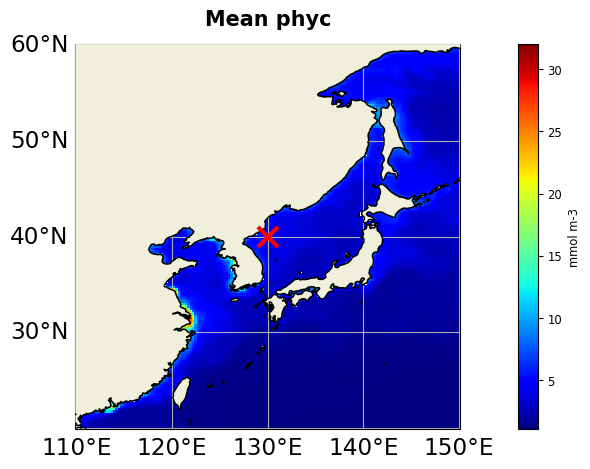

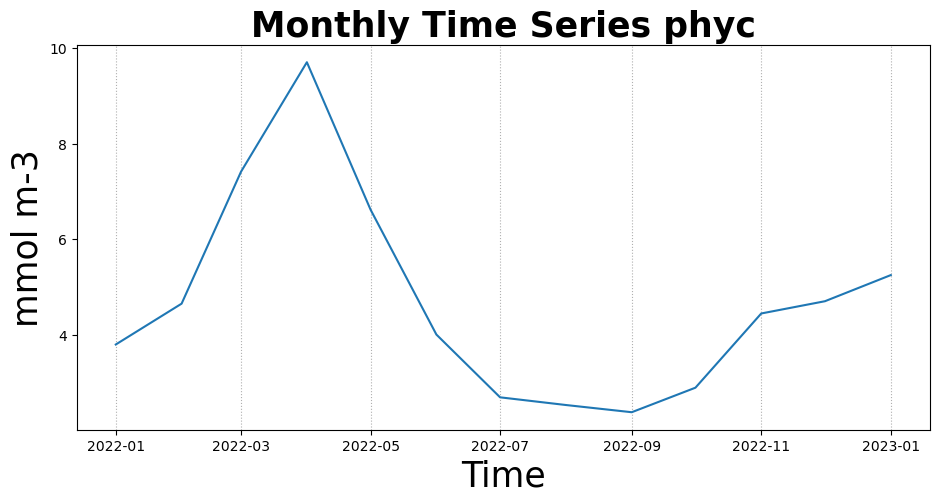

In [8]:
## Plots:

# Map
MapTitle = 'Mean {}'.format(VarName)
PlotMap(Data2Map2, MapTitle, Data2TS.units)
plt.plot(Lon, Lat, 'xr', markersize=15, markeredgewidth=3, zorder=100)

# Time series
def PlotTimeSeries(Data, Title, Units):
    Fig = plt.figure(figsize=(11, 5))
    Ax = plt.axes()
    plt.plot(Data['time'], Data)
    plt.rcParams['font.size'] = 20
    plt.xlabel('Time', fontsize=25)                                       # add label to x-axis
    plt.ylabel(Units, fontsize=25)                                        # add label to y-axis
    plt.grid(axis='x', linestyle=':')                                     #
    plt.title(Title, fontsize=25, fontweight="bold")                      # add a title to the figure
    return Fig, Ax

TitleTS = 'Monthly Time Series {}'.format(VarName)
PlotTimeSeries(Data2TS, TitleTS, Data2TS.units)

# <span style="color: #22689B;">**5. Conclusions**</span>
[Go back to the "Table of Contents"](#Table-of-Contents)

<div class="alert alert-block alert-success">
    <b>Congratulations!</b> You have successfully completed the introductory tutorial on using and visualizing Copernicus Marine Biogeochemical Products. Throughout this tutorial, we have explained the basic tools necessary to access and visualize gridded Copernicus Marine data.
<br><br>
In this tutorial, you acquired all the information you need to:

* Download Copernicus Marine products using the web service.
* Download Copernicus Marine products using Copernicus Marine Toolbox.
* Access NetCDF datasets.
* Navigate through the different variables, dimensions and attributes of a NetCDF file.
* Select data subsets within a NetCDF file.
* Plot maps of any variable.
* Crop maps by selecting specific regions.
* Use logarithmic color scales.
* Plot maps of temporal averages.
* Plot time series of data.

We sincerely hope that you have enjoyed the tutorial and found useful information in it. Please keep in mind that the tutorial has a progressive difficulty, moving quickly from basic elements to intermediate levels. Our intention is for all users to find useful information tailored to their level.

We understand that, for a user without prior knowledge, fully understanding all the procedures in the tutorial may be a challenge that requires some effort. However, we encourage everyone to take on the challenge as this is just the beginning of a journey towards a new understanding of the ocean and its ecosystems.

The final exercise proposed in this tutorial is designed for students to put into practice all the knowledge acquired throughout the course. We recommend that less advanced users approach it constructively and with awareness of their own limitations.
</div>

***
<div class="alert alert-block alert-info">
    
<h3>Final Exercise:</h3>

* Use the previous code to plot a map of average Chlorophyle concentration during year 2015 using the folowing Copernicus Dataset obtained from Satelite data.
    
    
    
    |  |  |
| :---: | :---|
| **Copernicus product** | GLOBAL_ANALYSISFORECAST_BGC_001_028 |
| **Datasets** | cmems_mod_glo_bgc-pft_anfc_0.25deg_P1M-m |
| **Dates** | Any desired period including at least few months.<br>For example: Form May 2022 to May 2023 |
    
    
</div>

***